<H1>Task 1: Cleaning and EDA<H1>

First I import the relevant packages for EDA and nd cleaning data.

In [30]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
import re
from thefuzz import process, fuzz
from datetime import datetime
from scipy import stats

In the next chunk, I load the dataset into a DataFrame.

In [3]:
purchase_data = pd.read_csv("purchase_behaviour.csv")
transaction_data_xls = pd.ExcelFile('transaction_data.xlsx')
transaction_data = transaction_data_xls.parse('in')

In this step I check the first few rows of the data to get an idea of its structure and contents. In the first snippet I view the purchase data, in the second I view the transaction data.

In [4]:
print(purchase_data.head())

   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004   OLDER SINGLES/COUPLES       Mainstream
4            1005  MIDAGE SINGLES/COUPLES       Mainstream


In [5]:
print(transaction_data.head())

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  


<H2>Transaction data </H2>

In this part I will focus on cleaning and organising the transaction data as I believe it requires a bit more attention. One thing that I noticed is that product name contains both the company name, flavour and weight of the chips. This makes it difficult to identify individual products.

In [6]:
unq_product_names = transaction_data['PROD_NAME'].unique()
print(unq_product_names)

<StringArray>
[  'Natural Chip        Compny SeaSalt175g',
                 'CCs Nacho Cheese    175g',
   'Smiths Crinkle Cut  Chips Chicken 170g',
   'Smiths Chip Thinly  S/Cream&Onion 175g',
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
 'Old El Paso Salsa   Dip Tomato Mild 300g',
 'Smiths Crinkle Chips Salt & Vinegar 330g',
    'Grain Waves         Sweet Chilli 210g',
  'Doritos Corn Chip Mexican Jalapeno 150g',
    'Grain Waves Sour    Cream&Chives 210G',
 ...
         'Doritos Cheese      Supreme 330g',
      'Smiths Crinkle Cut  Snag&Sauce 150g',
   'WW Sour Cream &OnionStacked Chips 160g',
                 'RRD Lime & Pepper   165g',
   'Natural ChipCo Sea  Salt & Vinegr 175g',
    'Red Rock Deli Chikn&Garlic Aioli 150g',
      'RRD SR Slow Rst     Pork Belly 150g',
                 'RRD Pc Sea Salt     165g',
       'Smith Crinkle Cut   Bolognese 150g',
                 'Doritos Salsa Mild  300g']
Length: 114, dtype: str


I noticed that one of the easiet things to remove into a separate column is weight

In [7]:
transaction_data["WEIGHT"] = transaction_data["PROD_NAME"].str.extract(r"(\d+)g", flags=re.IGNORECASE)
print(transaction_data['WEIGHT'].head())
#Everything worked smoothly so now I can remove the weight from the product name.

transaction_data["PROD_NAME"] = transaction_data["PROD_NAME"].str.replace(r"\d+g", "",flags=re.IGNORECASE, regex=True)
print(transaction_data['PROD_NAME'].head())

del unq_product_names #I don't need this anymore so I will delete

0    175
1    175
2    170
3    175
4    150
Name: WEIGHT, dtype: str
0      Natural Chip        Compny SeaSalt
1                    CCs Nacho Cheese    
2      Smiths Crinkle Cut  Chips Chicken 
3      Smiths Chip Thinly  S/Cream&Onion 
4    Kettle Tortilla ChpsHny&Jlpno Chili 
Name: PROD_NAME, dtype: str


In [8]:
unq_product_names = transaction_data["PROD_NAME"].unique()
print(unq_product_names)  

<StringArray>
[  'Natural Chip        Compny SeaSalt',
                 'CCs Nacho Cheese    ',
   'Smiths Crinkle Cut  Chips Chicken ',
   'Smiths Chip Thinly  S/Cream&Onion ',
 'Kettle Tortilla ChpsHny&Jlpno Chili ',
 'Old El Paso Salsa   Dip Tomato Mild ',
 'Smiths Crinkle Chips Salt & Vinegar ',
    'Grain Waves         Sweet Chilli ',
  'Doritos Corn Chip Mexican Jalapeno ',
    'Grain Waves Sour    Cream&Chives ',
 ...
         'Doritos Cheese      Supreme ',
      'Smiths Crinkle Cut  Snag&Sauce ',
   'WW Sour Cream &OnionStacked Chips ',
                 'RRD Lime & Pepper   ',
   'Natural ChipCo Sea  Salt & Vinegr ',
    'Red Rock Deli Chikn&Garlic Aioli ',
      'RRD SR Slow Rst     Pork Belly ',
                 'RRD Pc Sea Salt     ',
       'Smith Crinkle Cut   Bolognese ',
                 'Doritos Salsa Mild  ']
Length: 114, dtype: str


In [9]:
# Exporting the names of the products into a csv to later create a dictionary
# Convert to DataFrame
df_unique_products = pd.DataFrame(unq_product_names, columns=["PROD_NAME"])

# Export to CSV
df_unique_products.to_csv("unique_product_names.csv", index=False)

I used a Calude Sonet to identify canonical brands and build a list which I will use to seperate brand name from flavour. In the next step I will create a dictionary and custom function that I will use to for cleaning up the product name data and seprating Flavour from the brand

In [10]:
brand_lookup = {
    "Natural Chip": "Natural Chip Co",
    "Natural ChipCo": "Natural Chip Co",
    "Natural Chip Co": "Natural Chip Co",
    "NCC": "Natural Chip Co",
    "Smiths": "Smiths",
    "Smith": "Smiths",
    "Kettle": "Kettle",
    "Old El Paso": "Old El Paso",
    "Grain Waves": "Grain Waves",
    "GrnWves": "Grain Waves",
    "Doritos": "Doritos",
    "Dorito": "Doritos",
    "Twisties": "Twisties",
    "WW": "Woolworths",
    "Woolworths": "Woolworths",
    "Thins": "Thins",
    "Burger Rings": "Burger Rings",
    "CCs": "CCs",
    "Cheezels": "Cheezels",
    "Cheetos": "Cheetos",
    "Infuzions": "Infuzions",
    "Infzns": "Infuzions",
    "Pringles": "Pringles",
    "Red Rock Deli": "Red Rock Deli",
    "RRD": "Red Rock Deli",
    "Cobs": "Cobs",
    "French Fries": "French Fries",
    "Tostitos": "Tostitos",
    "Tyrrells": "Tyrrells",
    "Snbts": "Sunbites",
    "Sunbites": "Sunbites",
}

sorted_brands = sorted(brand_lookup.keys(), key=len, reverse=True)


def extract_brand(data):
    def _extract(name):
        name_clean = re.sub(r"\s+", " ", name).strip()
        for b in sorted_brands:
            if name_clean.lower().startswith(b.lower()):
                return brand_lookup[b]
        return "Unknown"

    if isinstance(data, pd.Series):
        return data.apply(_extract)
    return _extract(data)


def extract_flavour(data):
    def _extract(name):
        name_clean = re.sub(r"\s+", " ", name).strip()
        for b in sorted_brands:
            if name_clean.lower().startswith(b.lower()):
                flavour = name_clean[len(b) :].strip()
                return flavour if flavour else "Original"
        return name_clean

    if isinstance(data, pd.Series):
        return data.apply(_extract)
    return _extract(data)


transaction_data["BRAND"] = extract_brand(transaction_data["PROD_NAME"])
transaction_data["FLAVOUR"] = extract_flavour(transaction_data["PROD_NAME"])

I maanaged to standartise the chip brand names to just 21 different brand names (from 114), the step would be to standartise the flavours column

In [11]:
# Step 1: Get unique flavaour names from the
unq_flavours = transaction_data["FLAVOUR"].unique()
print(unq_flavours)

# Step 2: Create a DataFrame with the uniqe flavours
# Convert to DataFrame
df_unique_flavours = pd.DataFrame(unq_flavours, columns=["PROD_NAME"])

# Export to CSV
df_unique_flavours.to_csv("unique_product_names.csv", index=False)

<StringArray>
[                  'mpny SeaSalt',                   'Nacho Cheese',
      'Crinkle Cut Chips Chicken',      'Chip Thinly S/Cream&Onion',
   'Tortilla ChpsHny&Jlpno Chili',          'Salsa Dip Tomato Mild',
   'Crinkle Chips Salt & Vinegar',                   'Sweet Chilli',
     'Corn Chip Mexican Jalapeno',              'Sour Cream&Chives',
 ...
                 'Cheese Supreme',         'Crinkle Cut Snag&Sauce',
 'Sour Cream &OnionStacked Chips',                  'Lime & Pepper',
              'Sea Salt & Vinegr',             'Chikn&Garlic Aioli',
         'SR Slow Rst Pork Belly',                    'Pc Sea Salt',
          'Crinkle Cut Bolognese',                     'Salsa Mild']
Length: 110, dtype: str


In this part I will clean up the FLAVOUR column to standartise the flavour and brand names. The below dictionaries were built using a large language model (deepseek-v3.1:671b), which was prompted to analyse the data, identify common brand names and create a dictionary.

In [12]:
noise_prefixes = sorted(
    [
        "Corn Chips",
        "Corn Chip",
        "Corn Chp",
        "Potato Chips",
        "Potato Chip",
        "Crinkle Cut Chips",
        "Crinkle Cut Chip",
        "Crinkle Chips",
        "Crinkle Chip",
        "Crinkle Cut",
        "Crinkle",
        "Crnkle Chip",
        "Chip Thinly Cut",
        "Chip Thinly",
        "Thinly Cut",
        "Thinly",
        "Tortilla Chps",
        "Tortilla Chips",
        "Tortilla Chip",
        "Chips",
        "Chip",
        "Crisps",
        "Crisp",
        "Sensations",
        "Popd",
        "Whlgrn Crisps",
        "Whlegrn Crisps",
        "Salsa Dip",
        "D/Style Chip",
        "Plus",
        "SR",
        "Pc",
    ],
    key=len,
    reverse=True,
)

abbrev_lookup = {
    "Hny&Jlpno Chili": "Honey & Jalapeno Chilli",
    "Swt Chli&S/Cream": "Sweet Chilli & Sour Cream",
    "S/Cream&Onion": "Sour Cream & Onion",
    "Sour Crm &Chives Chips": "Sour Cream & Chives",
    "Sour Cream&Chives": "Sour Cream & Chives",
    "Sourcream Onion": "Sour Cream & Onion",
    "Sourcream&Herbs Veg Strws": "Sour Cream & Herbs Veg Straws",
    "Sour Cream &Onionstacked Chips": "Sour Cream & Onion",
    "Chs&Onion": "Cheese & Onion",
    "Chs & Bacon Balls": "Cheese & Bacon Balls",
    "Btroot & Chilli Jam": "Beetroot & Chilli Jam",
    "Btroot&Ricotta": "Beetroot & Ricotta",
    "Feta&Garlic": "Feta & Garlic",
    "Chikn&Garlic Aioli": "Chicken & Garlic Aioli",
    "Hony Soy Chckn": "Honey Soy Chicken",
    "Tmato Hrb&Spce": "Tomato Herb & Spice",
    "Frch/Onin": "French Onion",
    "French Oniondip": "French Onion Dip",
    "Cheddr&Mstrd": "Cheddar & Mustard",
    "Ched & Chives": "Cheddar & Chives",
    "Sthrn Friedchicken": "Southern Fried Chicken",
    "Seasonedchicken": "Seasoned Chicken",
    "Sweet&Spcy Bbq": "Sweet & Spicy BBQ",
    "Bbq&Maple": "BBQ & Maple",
    "Orgnl Big Bag": "Original Big Bag",
    "Originl Saltd": "Original Salted",
    "Slt Vingar": "Salt & Vinegar",
    "Salt/Vinegr": "Salt & Vinegar",
    "Sea Salt & Vinegr": "Sea Salt & Vinegar",
    "Sea Salt And Vinegar": "Sea Salt & Vinegar",
    "Swt Pot Sea Salt": "Sweet Potato Sea Salt",
    "Swt/Chlli &Sr/Cream Chips": "Sweet Chilli & Sour Cream",
    "Snag&Sauce": "Sausage & Sauce",
    "Chnky Tom Ht": "Chunky Tomato Hot",
    "Tomato Med": "Tomato Medium",
    "Salsa Medium": "Medium Salsa",
    "Mango Chutny Papadums": "Mango Chutney Papadums",
    "Steak & Chimuchurri": "Steak & Chimichurri",
    "Slow Rst Pork Belly": "Slow Roast Pork Belly",
    "Crn Crnchers Tangy Gcamole": "Tangy Guacamole",
    "Mpny Seasalt": "Sea Salt",
    "Sea Salt Chips": "Sea Salt",
    "Thai Sweetchili Potatomix": "Thai Sweet Chilli Potato Mix",
    "Light& Tangy": "Light & Tangy",
    "Chilli& Coconut": "Chilli & Coconut",
    "Salsa & Mzzrlla": "Salsa & Mozzarella",
    "Siracha Lime": "Sriracha Lime",
    "Bbq Rib Prawn Crackers": "BBQ Rib Prawn Crackers",
    "Chicken Salt Crips": "Chicken Salt Crisps",
    "Sp Salt & Truffle": "Salt & Truffle",
}


def clean_flavour(data):
    def _clean(name):
        name_clean = re.sub(r"\s+", " ", name).strip()
        for prefix in noise_prefixes:
            name_clean = re.sub(
                r"^" + re.escape(prefix) + r"\s*", "", name_clean, flags=re.IGNORECASE
            ).strip()
        name_titled = re.sub(r"\bBbq\b", "BBQ", name_clean.title())
        for abbrev, canonical in abbrev_lookup.items():
            if name_titled.lower() == abbrev.lower():
                return canonical
        return name_titled if name_titled else "Original"

    if isinstance(data, pd.Series):
        return data.apply(_clean)
    return _clean(data)


transaction_data["FLAVOUR"] = clean_flavour(transaction_data["FLAVOUR"])

Having cleaned and processed the product column, I will clean up the data frame and work environment

In [13]:
del transaction_data['PROD_NAME']
del abbrev_lookup
del brand_lookup
del df_unique_flavours
del df_unique_products
del noise_prefixes
del sorted_brands
del transaction_data_xls
del unq_flavours
del unq_product_names

<b>Ensuring that the data is of the correct type</b>

In the following section I will ensure that the columns are in the correct datatypes. There are no missing values in the dataframe.

In [14]:
print(transaction_data.dtypes)

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_QTY            int64
TOT_SALES         float64
WEIGHT                str
BRAND                 str
FLAVOUR               str
dtype: object


The date is of the wrong data type so is the weight column. Brand and Flavour will be converted to categorical data types.

In [15]:
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'], unit='D', origin='1899-12-30')
transaction_data['WEIGHT'] = transaction_data['WEIGHT'].astype(float)
transaction_data['BRAND'] = transaction_data['BRAND'].astype('category')
transaction_data['FLAVOUR'] = transaction_data['FLAVOUR'].astype('category')

I do a final check to make sure that the data types are correct.

In [16]:
print(transaction_data.dtypes)

DATE              datetime64[s]
STORE_NBR                 int64
LYLTY_CARD_NBR            int64
TXN_ID                    int64
PROD_NBR                  int64
PROD_QTY                  int64
TOT_SALES               float64
WEIGHT                  float64
BRAND                  category
FLAVOUR                category
dtype: object


<h2>Purchase data</h2>>
After cleaning and brining transaction data in order, its time to clean up the purchase data. I used the Data Wrangler extension from Microsoft to get a high level view of the columns, and there was no missing data. So I will mostly focus on grouping and ungrouping rows.

In [17]:
#In the first step I want to view some descriptive stastics about the columns and data
print(purchase_data.dtypes)

LYLTY_CARD_NBR      int64
LIFESTAGE             str
PREMIUM_CUSTOMER      str
dtype: object


In [18]:
# I think lifestage is an intersting column wirth giving extra attention to
print(purchase_data['LIFESTAGE'].value_counts())
# I will convert the LIFESTAGE and PREMIUM_CUSTOMER columns into a category type
purchase_data['LIFESTAGE'] = purchase_data['LIFESTAGE'].astype('category')
purchase_data["PREMIUM_CUSTOMER"] = purchase_data["PREMIUM_CUSTOMER"].astype('category')
#Checking if the coversion was successful
print(purchase_data.dtypes)

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64
LYLTY_CARD_NBR         int64
LIFESTAGE           category
PREMIUM_CUSTOMER    category
dtype: object


<h2>EDA and merging</h2>
In this part I will preform EDA and merging of the purchase and transaction data to derrive insights.  I will look at different features such as LIFESTAGE, PREMIUM_CUSTOMER, and PURCHASE_AMT to see if there are any correlations between them. I wil also examine the data by different groupings to see which products are the most popular among which groups. I will use matplotlib and seaborn for visualization.

In [19]:
#In this part I am merging purchase data with transaction data on loyalty card number
merged_data = pd.merge(transaction_data, purchase_data, on='LYLTY_CARD_NBR', how='left')
print(merged_data.head())

        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  PROD_QTY  \
0 2018-10-17          1            1000       1         5         2   
1 2019-05-14          1            1307     348        66         3   
2 2019-05-20          1            1343     383        61         2   
3 2018-08-17          2            2373     974        69         5   
4 2018-08-18          2            2426    1038       108         3   

   TOT_SALES  WEIGHT            BRAND                  FLAVOUR  \
0        6.0   175.0  Natural Chip Co                 Sea Salt   
1        6.3   175.0              CCs             Nacho Cheese   
2        2.9   170.0           Smiths                  Chicken   
3       15.0   175.0           Smiths       Sour Cream & Onion   
4       13.8   150.0           Kettle  Honey & Jalapeno Chilli   

                LIFESTAGE PREMIUM_CUSTOMER  
0   YOUNG SINGLES/COUPLES          Premium  
1  MIDAGE SINGLES/COUPLES           Budget  
2  MIDAGE SINGLES/COUPLES           Budge

In [20]:
#In this part I am checking for missing values in the merged data
print(merged_data.info())
print(merged_data.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype        
---  ------            --------------   -----        
 0   DATE              264836 non-null  datetime64[s]
 1   STORE_NBR         264836 non-null  int64        
 2   LYLTY_CARD_NBR    264836 non-null  int64        
 3   TXN_ID            264836 non-null  int64        
 4   PROD_NBR          264836 non-null  int64        
 5   PROD_QTY          264836 non-null  int64        
 6   TOT_SALES         264836 non-null  float64      
 7   WEIGHT            264836 non-null  float64      
 8   BRAND             264836 non-null  category     
 9   FLAVOUR           264836 non-null  category     
 10  LIFESTAGE         264836 non-null  category     
 11  PREMIUM_CUSTOMER  264836 non-null  category     
dtypes: category(4), datetime64[s](1), float64(2), int64(5)
memory usage: 17.2 MB
None
DATE                datetime64[s]
STORE_NBR              

There are no missing values in any of the columns. All of the variables are of the correct category type. In the next steps I will look into core metrics which are important to the current scenario:
1. Who are the most valuable customer segments?
2. How does purchasing behavior vary across different customer segments?
3. What are the product preferences of each segment?
4. What is the sales trend over time?

<H3>Insights about customer segments</H3>

Insight 1: Segment value and volume                  LIFESTAGE PREMIUM_CUSTOMER  total_sales  total_transactions  \
0   MIDAGE SINGLES/COUPLES           Budget     35514.80                5020   
1   MIDAGE SINGLES/COUPLES       Mainstream     90803.85               11874   
2   MIDAGE SINGLES/COUPLES          Premium     58432.65                8216   
3             NEW FAMILIES           Budget     21928.45                3005   
4             NEW FAMILIES       Mainstream     17013.90                2325   
5             NEW FAMILIES          Premium     11491.10                1589   
6           OLDER FAMILIES           Budget    168363.25               23160   
7           OLDER FAMILIES       Mainstream    103445.55               14244   
8           OLDER FAMILIES          Premium     81958.40               11192   
9    OLDER SINGLES/COUPLES           Budget    136769.80               18407   
10   OLDER SINGLES/COUPLES       Mainstream    133393.80               18318   
11  

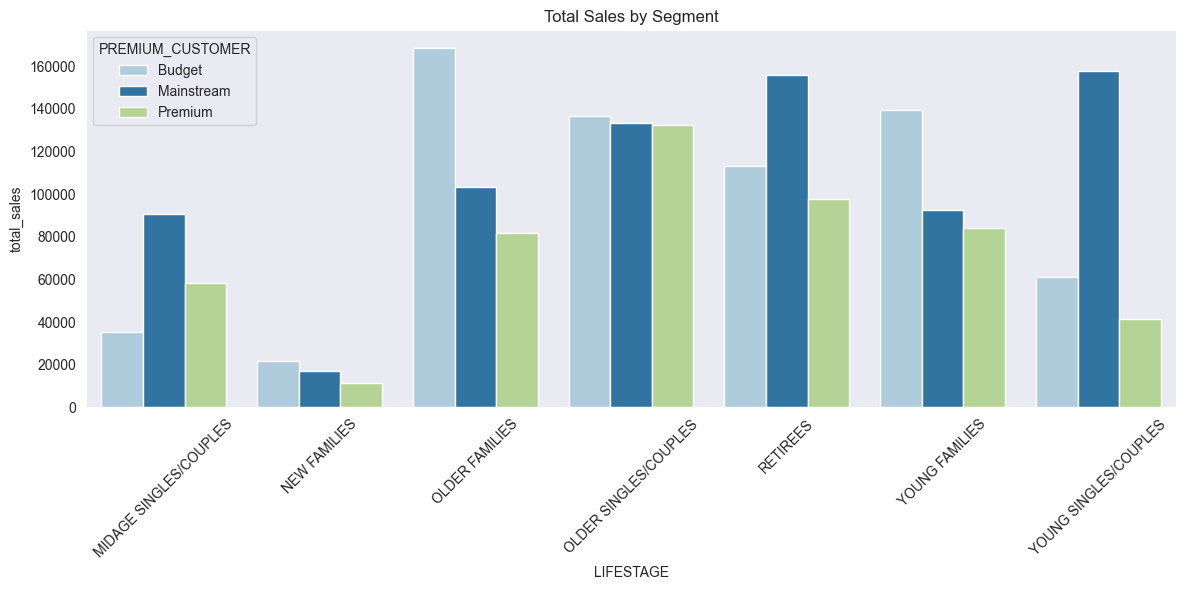

In [21]:
sns.set_style("dark")
sns.set_palette("Paired")

# Segment summary (value and volume)
segment_summary = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    total_sales=('TOT_SALES', 'sum'),
    total_transactions=('TXN_ID', 'count'), 
    unique_customers=('LYLTY_CARD_NBR', 'nunique')
).reset_index()

segment_summary['AVG_TRANS_Value'] = segment_summary['total_sales'] / segment_summary['total_transactions']
print(f'Insight 1: Segment value and volume {segment_summary}')

# Plotting total sales by segment
plt.figure(figsize=(12, 6))
sns.barplot(data=segment_summary, x='LIFESTAGE', y='total_sales', hue='PREMIUM_CUSTOMER')
plt.title('Total Sales by Segment')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Older Families represent the highest-value segment and should be the primary focus for retention and growth investment, while Older Singles/Couples and Retirees follow closely behind as strong secondary priorities. Across most segments, Budget customers lead in volume, but Retirees and Young Singles/Couples show a notable Mainstream skew suggesting these groups respond better to aspirational, lifestyle-oriented positioning rather than price-driven messaging. Premium remains the smallest tier universally, yet shows the most untapped potential in Older Singles/Couples and Retirees, where spending capacity exists and targeted upsell strategies could meaningfully grow revenue. At the other end of the spectrum, New Families consistently underperform across all tiers, signalling either a relevance gap or a need to reassess acquisition investment in this segment altogether.

<H3>Insights about Purchasing Behaviour</H3>

Insight 2: Purchasing behavior by segment                  LIFESTAGE PREMIUM_CUSTOMER  Total_Quantity  \
0   MIDAGE SINGLES/COUPLES           Budget            9496   
1   MIDAGE SINGLES/COUPLES       Mainstream           22699   
2   MIDAGE SINGLES/COUPLES          Premium           15526   
3             NEW FAMILIES           Budget            5571   
4             NEW FAMILIES       Mainstream            4319   
5             NEW FAMILIES          Premium            2957   
6           OLDER FAMILIES           Budget           45065   
7           OLDER FAMILIES       Mainstream           27756   
8           OLDER FAMILIES          Premium           22171   
9    OLDER SINGLES/COUPLES           Budget           35220   
10   OLDER SINGLES/COUPLES       Mainstream           34997   
11   OLDER SINGLES/COUPLES          Premium           33986   
12                RETIREES           Budget           28764   
13                RETIREES       Mainstream           40518   
14           

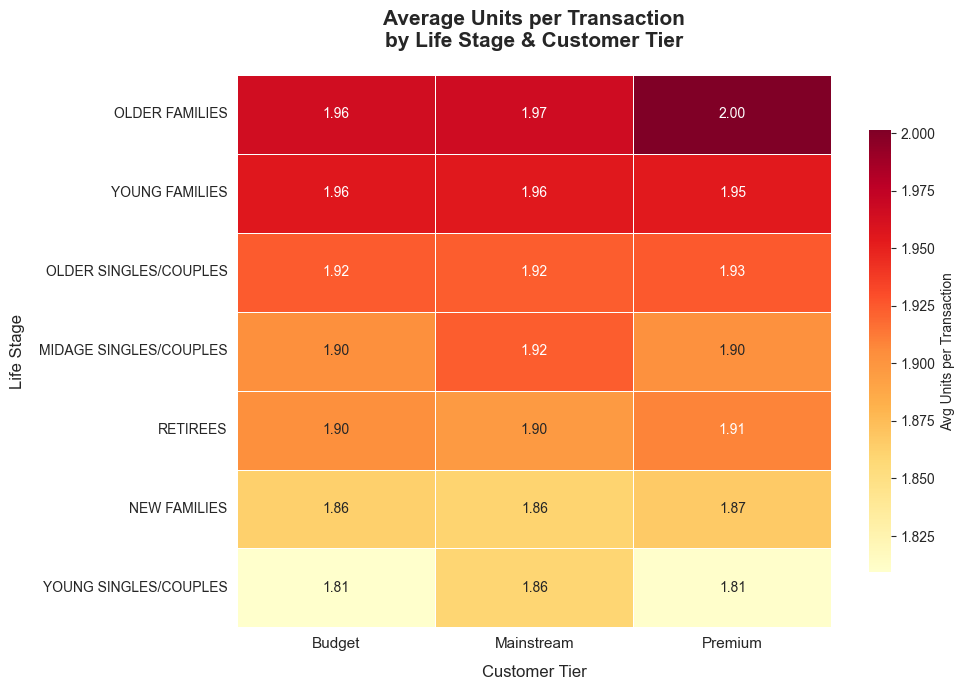

In [22]:
purchase_behavior = (
    merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .agg(Total_Quantity=("PROD_QTY", "sum"), Total_Transactions=("TXN_ID", "nunique"))
    .reset_index()
)

purchase_behavior["Avg_Units_per_Txn"] = (
    purchase_behavior["Total_Quantity"] / purchase_behavior["Total_Transactions"]
)
print(f'Insight 2: Purchasing behavior by segment {purchase_behavior}')

# Heatmap to visualise how many packets on average shoppers by per transaction
# Pivot to matrix form for heatmap
heatmap_data = purchase_behavior.pivot(
    index="LIFESTAGE", columns="PREMIUM_CUSTOMER", values="Avg_Units_per_Txn"
)

# Order columns logically
heatmap_data = heatmap_data[["Budget", "Mainstream", "Premium"]]

# Order rows by average (highest buying segments at top)
heatmap_data = heatmap_data.loc[
    heatmap_data.mean(axis=1).sort_values(ascending=False).index
]

#Plot
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    heatmap_data,
    annot=True,  # Show values in each cell
    fmt=".2f",  # 2 decimal places
    cmap="YlOrRd",  # Intuitive: light = low, dark = high
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Avg Units per Transaction", "shrink": 0.8},
    ax=ax,
)

#Labels & title
ax.set_title(
    "Average Units per Transaction\nby Life Stage & Customer Tier",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Customer Tier", fontsize=12, labelpad=10)
ax.set_ylabel("Life Stage", fontsize=12, labelpad=10)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10, rotation=0)  # Keep y-labels horizontal

plt.tight_layout()
plt.show()

Older Families and Young Families consistently purchase the most units per transaction across all customer tiers, with Older Families Premium customers reaching the highest basket size of 2.00, reinforcing their position as the most engaged and high-value segment. Basket size is notably stable across Budget, Mainstream, and Premium tiers within most segments, suggesting that purchasing behaviour is driven more by life stage than by spending tier. Young Singles/Couples and New Families sit at the bottom of the scale, indicating smaller, more selective purchases. However, Young Singles/Couples Mainstream customers (1.86) outpace their Budget and Premium counterparts, hinting at a Mainstream sweet spot for that group. The overall narrow range across the entire heatmap (1.81–2.00) signals that basket size is a relatively consistent metric, meaning meaningful revenue growth is more likely to come from increasing transaction frequency or customer acquisition than from driving larger individual purchases.

<H3>Flavour and Brand preference</H3>

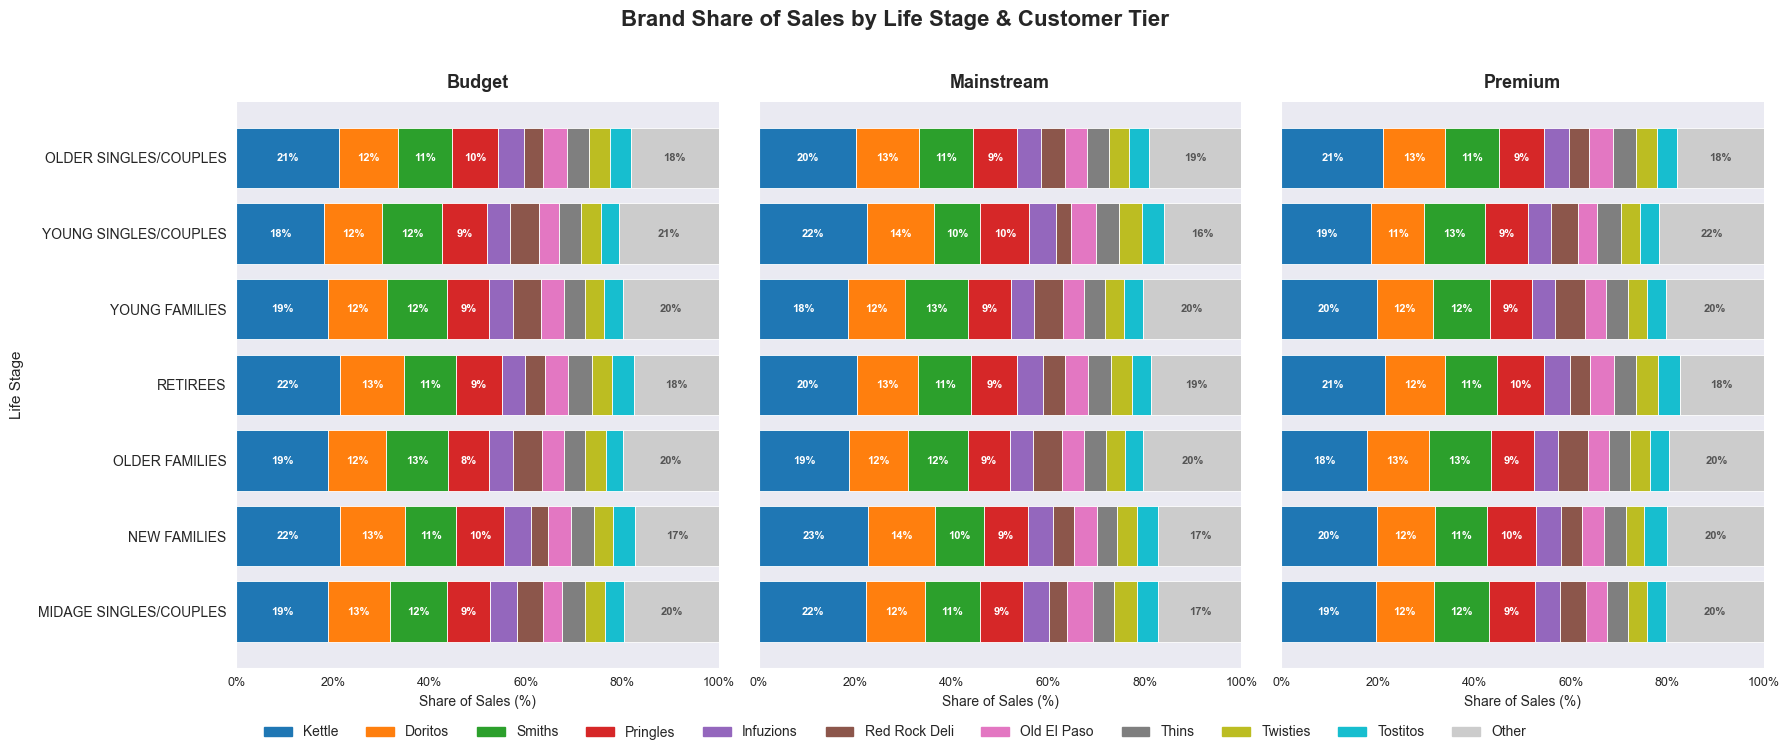

In [23]:
# Brand preference (what customer prefer to buy)
# Calculate total sales per segment for percentage calculation
total_sales_per_segment = (
    merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"]
    .sum()
    .rename("Total_Segment_Sales")
    .reset_index()
)

# Calculate sales for each brand within each segment
brand_share = (
    merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER", "BRAND"])["TOT_SALES"]
    .sum()
    .reset_index()
)
brand_share = brand_share.merge(
    total_sales_per_segment, on=["LIFESTAGE", "PREMIUM_CUSTOMER"]
)
brand_share["Share_of_Sales"] = (
    brand_share["TOT_SALES"] / brand_share["Total_Segment_Sales"]
) * 100

TOP_N = 10
top_brands = (
    brand_share.groupby("BRAND")["TOT_SALES"]
    .sum()
    .nlargest(TOP_N)
    .index.tolist()
)
brand_share["BRAND_GROUPED"] = brand_share["BRAND"].astype(str).where(
    brand_share["BRAND"].isin(top_brands), other="Other"
)

# Re-aggregate with grouped brands
plot_data = (
    brand_share.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER", "BRAND_GROUPED"])["Share_of_Sales"]
    .sum()
    .reset_index()
)

# Pivot for stacking
pivot = plot_data.pivot_table(
    index=["LIFESTAGE", "PREMIUM_CUSTOMER"],
    columns="BRAND_GROUPED",
    values="Share_of_Sales",
    fill_value=0,
)

# Order brands: top brands first, "Other" last
brand_order = top_brands + ["Other"]
brand_order = [b for b in brand_order if b in pivot.columns]
pivot = pivot[brand_order]

# Logical column order
tier_order = ["Budget", "Mainstream", "Premium"]

# Sort life stages by total share of top brand (consistent ordering across facets)
lifestage_order = (
    plot_data.groupby("LIFESTAGE")["Share_of_Sales"]
    .sum()
    .sort_values(ascending=True)
    .index.tolist()
)

# Colour palette
# Distinct colours for brands, grey for Other
palette = sns.color_palette("tab10", n_colors=TOP_N)
colors = {brand: palette[i] for i, brand in enumerate(top_brands)}
colors["Other"] = "#cccccc"

# Plot: one facet per customer tier
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.suptitle(
    "Brand Share of Sales by Life Stage & Customer Tier",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

for ax, tier in zip(axes, tier_order):
    # Slice data for this tier
    tier_data = pivot.xs(tier, level="PREMIUM_CUSTOMER").reindex(lifestage_order)

    # Plot stacked bars
    bottom = np.zeros(len(tier_data))
    for brand in brand_order:
        if brand not in tier_data.columns:
            continue
        values = tier_data[brand].values
        ax.barh(
            lifestage_order,
            values,
            left=bottom,
            color=colors[brand],
            edgecolor="white",
            linewidth=0.6,
            label=brand,
        )
        # Annotate segments wider than 8% to avoid clutter
        for i, (val, bot) in enumerate(zip(values, bottom)):
            if val > 8:
                ax.text(
                    bot + val / 2,
                    i,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if brand != "Other" else "#555555",
                    fontweight="bold",
                )
        bottom += values

    # Formatting per facet
    ax.set_title(tier, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Share of Sales (%)", fontsize=10)
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%g%%"))
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)

# Shared y-label on leftmost axis only
axes[0].set_ylabel("Life Stage", fontsize=11, labelpad=10)

# Single shared legend below the charts
legend_handles = [
    mpatches.Patch(color=colors[b], label=b) for b in brand_order
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(brand_order),
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()
plt.show()

Kettle dominates uniformly, but the real story is how little segments differ. Kettle leads every life stage and tier combination with roughly 18-23% share, followed consistently by Doritos (11-14%), Smiths (10-13%), and Pringles (8-10%) — a top-4 lock that holds across all 21 segments. The striking takeaway is not who wins, but how stable the hierarchy is: no brand meaningfully over-indexes in a specific segment, and "Other" (16-22%) suggests the remaining shelf space is fragmented across many minor brands with no breakout performer. The one subtle signal worth noting is that Kettle skews slightly stronger among Retirees and Older Singles/Couples across all three tiers, while Young Singles/Couples show marginally higher Other share — hinting at younger shoppers being slightly more exploratory in brand choice. For strategy, the uniformity across Budget, Mainstream, and Premium is the most actionable finding: premium-tier customers are not trading up to a different brand, they are buying the same brands as budget customers, which suggests pricing and pack-size differentiation rather than brand preference is likely driving tier differences.

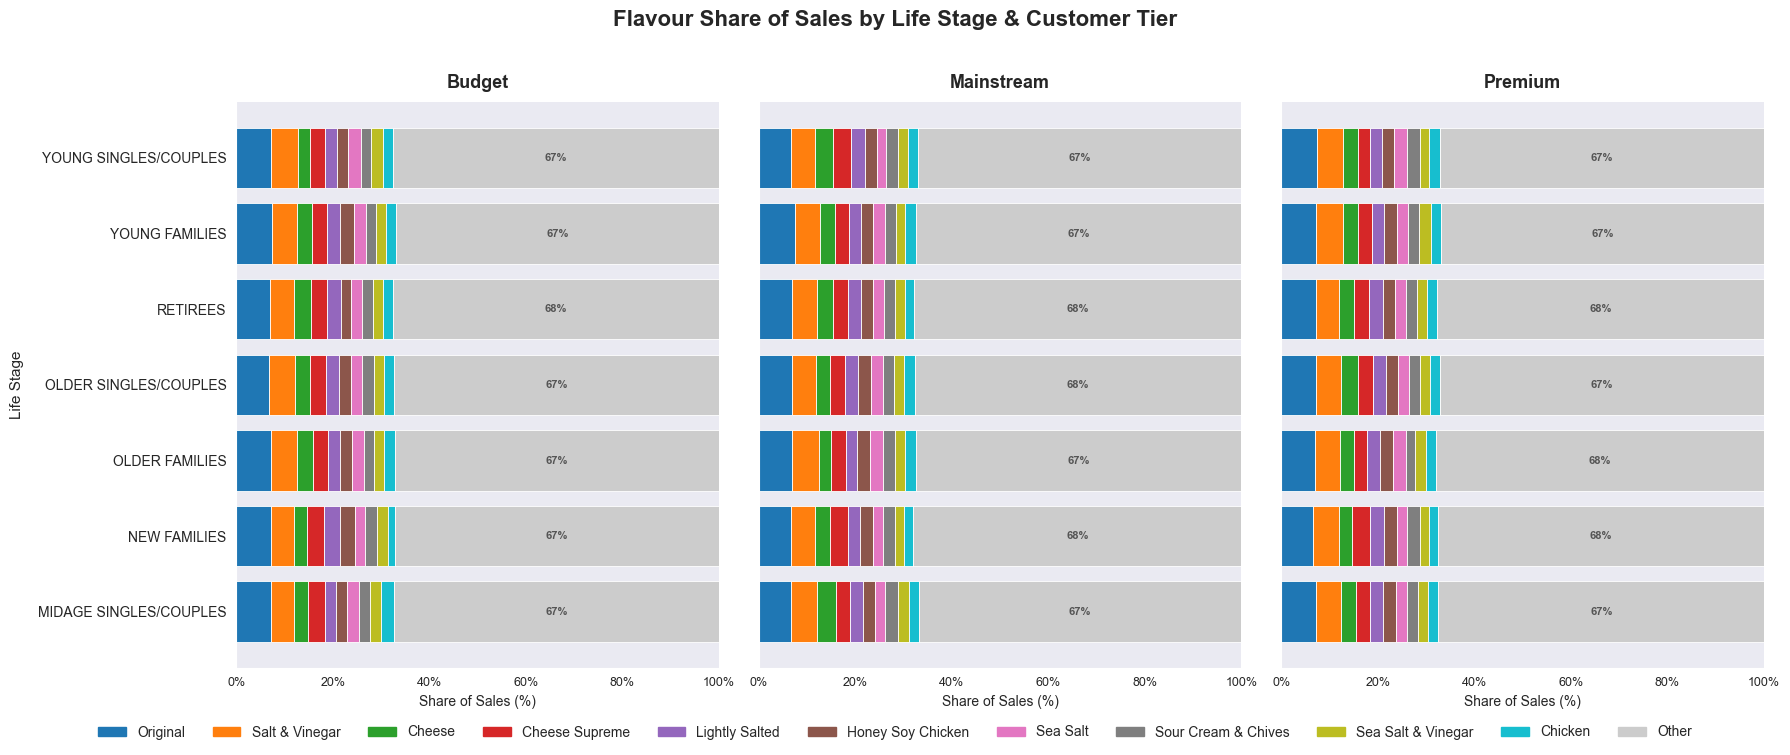

In [24]:
# Calculate sales for each FLAVOUR within each segment
flavour_share = (
    merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER", "FLAVOUR"])["TOT_SALES"]
    .sum()
    .reset_index()
)
flavour_share = flavour_share.merge(
    total_sales_per_segment, on=["LIFESTAGE", "PREMIUM_CUSTOMER"]
)
flavour_share["Share_of_Sales"] = (
    flavour_share["TOT_SALES"] / flavour_share["Total_Segment_Sales"]
) * 100

TOP_N = 10
top_flavours = (
    flavour_share.groupby("FLAVOUR")["TOT_SALES"].sum().nlargest(TOP_N).index.tolist()
)
flavour_share["FLAVOUR_GROUPED"] = (
    flavour_share["FLAVOUR"]
    .astype(str)
    .where(flavour_share["FLAVOUR"].isin(top_flavours), other="Other")
)

plot_data = (
    flavour_share.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER", "FLAVOUR_GROUPED"])[
        "Share_of_Sales"
    ]
    .sum()
    .reset_index()
)

pivot = plot_data.pivot_table(
    index=["LIFESTAGE", "PREMIUM_CUSTOMER"],
    columns="FLAVOUR_GROUPED",
    values="Share_of_Sales",
    fill_value=0,
)

flavour_order = top_flavours + ["Other"]
flavour_order = [f for f in flavour_order if f in pivot.columns]
pivot = pivot[flavour_order]

tier_order = ["Budget", "Mainstream", "Premium"]
lifestage_order = (
    plot_data.groupby("LIFESTAGE")["Share_of_Sales"]
    .sum()
    .sort_values(ascending=True)
    .index.tolist()
)

palette = sns.color_palette("tab10", n_colors=TOP_N)
colors = {flavour: palette[i] for i, flavour in enumerate(top_flavours)}
colors["Other"] = "#cccccc"

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.suptitle(
    "Flavour Share of Sales by Life Stage & Customer Tier",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

for ax, tier in zip(axes, tier_order):
    tier_data = pivot.xs(tier, level="PREMIUM_CUSTOMER").reindex(lifestage_order)

    bottom = np.zeros(len(tier_data))
    for flavour in flavour_order:
        if flavour not in tier_data.columns:
            continue
        values = tier_data[flavour].values
        ax.barh(
            lifestage_order,
            values,
            left=bottom,
            color=colors[flavour],
            edgecolor="white",
            linewidth=0.6,
            label=flavour,
        )
        for i, (val, bot) in enumerate(zip(values, bottom)):
            if val > 8:
                ax.text(
                    bot + val / 2,
                    i,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if flavour != "Other" else "#555555",
                    fontweight="bold",
                )
        bottom += values

    ax.set_title(tier, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Share of Sales (%)", fontsize=10)
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0f}%")
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Life Stage", fontsize=11, labelpad=10)

legend_handles = [mpatches.Patch(color=colors[f], label=f) for f in flavour_order]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(flavour_order),
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()
plt.show()

Flavour preferences are remarkably uniform, with fragmentation being the defining characteristic. Original leads every segment as the top flavour, followed closely by Salt & Vinegar and Cheese, but no single flavour commands a dominant share — the top 10 named flavours collectively only account for roughly 32-33% of sales, with "Other" holding a near-constant 67-68% across all 21 segment combinations. This extreme fragmentation means the flavour landscape is far more competitive and spread-out than the brand landscape, where Kettle clearly anchored the market. The consistency of "Other" at exactly 67-68% regardless of life stage or customer tier is itself a key finding: premium customers are not gravitating toward distinct flavour profiles, and neither are any particular life stage groups — suggesting flavour choice is more of a personal preference than a demographic signal. For strategy, this uniformity argues against segment-specific flavour promotions, and instead points toward ensuring broad flavour variety is stocked across all store types, since no segment shows enough differentiation to justify a targeted ranging decision based on demographic profile alone.

<H3>Temporal analysis</H3>

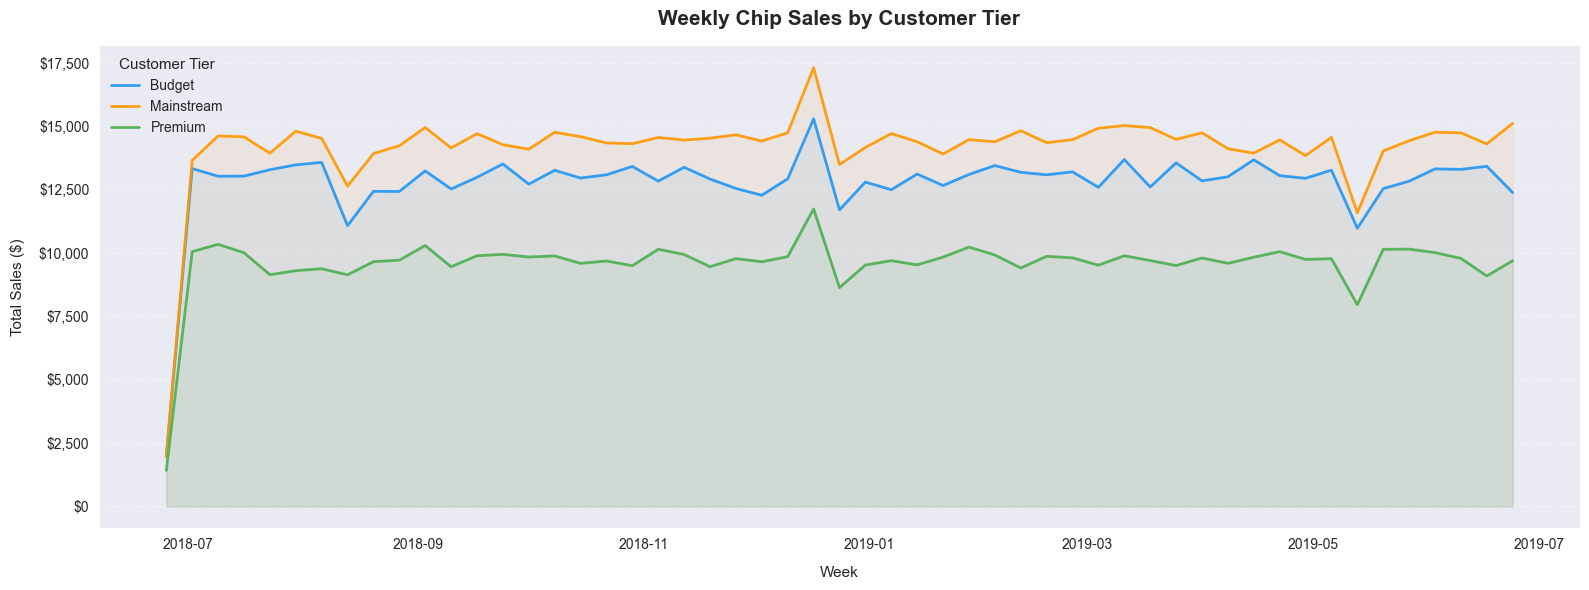

In [25]:
#Data prep
merged_data["WEEK"] = merged_data["DATE"].dt.to_period("W").dt.start_time

weekly_segment = (
    merged_data.groupby(["WEEK", "PREMIUM_CUSTOMER"])["TOT_SALES"].sum().reset_index()
)

# --- Plot ---
tier_colors = {
    "Budget": "#2196F3",
    "Mainstream": "#FF9800",
    "Premium": "#4CAF50",
}

fig, ax = plt.subplots(figsize=(16, 6))

for tier, group in weekly_segment.groupby("PREMIUM_CUSTOMER"):
    ax.plot(
        group["WEEK"],
        group["TOT_SALES"],
        label=tier,
        color=tier_colors[tier],
        linewidth=2,
        alpha=0.9,
    )
    # Shade under each line for readability
    ax.fill_between(
        group["WEEK"],
        group["TOT_SALES"],
        alpha=0.08,
        color=tier_colors[tier],
    )

# --- Formatting ---
ax.set_title(
    "Weekly Chip Sales by Customer Tier",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Week", fontsize=11, labelpad=10)
ax.set_ylabel("Total Sales ($)", fontsize=11, labelpad=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Customer Tier", fontsize=10, title_fontsize=11, frameon=False)

plt.tight_layout()
plt.show()

Across the full fiscal year from mid-2018 to mid-2019, the Mainstream tier consistently dominates revenue, hovering between $13,000–$15,000 weekly, while the Budget tier tracks closely beneath it at roughly $12,500–$13,500 — a surprisingly narrow gap that suggests Budget customers are nearly as valuable in aggregate as Mainstream ones. The Premium tier, though the lowest of the three at around $9,500–$10,500, remains remarkably stable, indicating a loyal and predictable high-value customer base. The most notable event is the sharp synchronized spike near January 2019, where Mainstream surged to ~$17,000 and Budget briefly overtook its usual range before both sharply corrected — likely driven by a seasonal or promotional event. A corresponding dip in Premium at the same moment hints at possible customer substitution or a demand shift during that period. The late-May 2019 trough across all three tiers is another red flag worth investigating, as it represents the most broad-based weakness in the entire year. Overall, the business is heavily reliant on its Mainstream segment, and the near-parity between Budget and Mainstream volumes warrants a strategic review of pricing architecture to ensure margin is not being left on the table.

<H3>Outliers</H3>
There are two outliers in the data set under product quantity, so those need to be removed.

In [26]:
# Inspect the outlier first
print(merged_data[merged_data["PROD_QTY"] == 200])

# Remove it
merged_data = merged_data[merged_data["PROD_QTY"] < 200]

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  PROD_QTY  \
69762 2018-08-19        226          226000  226201         4       200   
69763 2019-05-20        226          226000  226210         4       200   

       TOT_SALES  WEIGHT    BRAND  FLAVOUR       LIFESTAGE PREMIUM_CUSTOMER  \
69762      650.0   380.0  Doritos  Supreme  OLDER FAMILIES          Premium   
69763      650.0   380.0  Doritos  Supreme  OLDER FAMILIES          Premium   

            WEEK  
69762 2018-08-13  
69763 2019-05-20  


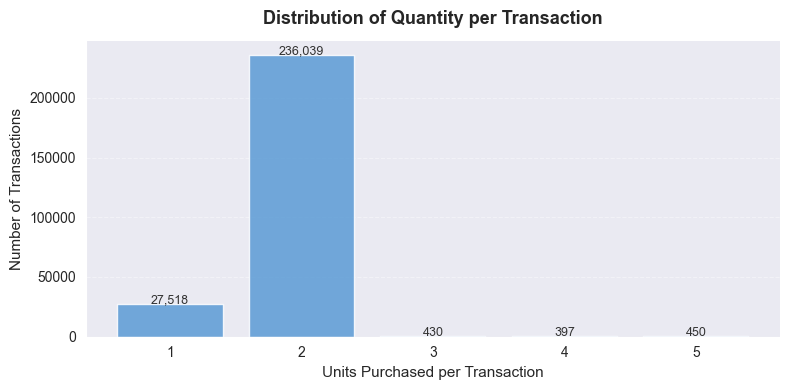

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

qty_counts = merged_data["PROD_QTY"].value_counts().sort_index()

ax.bar(
    qty_counts.index, qty_counts.values, color="#5B9BD5", alpha=0.85, edgecolor="white"
)

ax.set_title(
    "Distribution of Quantity per Transaction", fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Units Purchased per Transaction", fontsize=11)
ax.set_ylabel("Number of Transactions", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Annotate bars with counts
for x, y in zip(qty_counts.index, qty_counts.values):
    ax.text(x, y + 200, f"{y:,}", ha="center", fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

The two single 200 pack purchases were removed as they didn't seem like normal consumer behaviour. From the countplot it seems that most people purchase between 1 and 5 units per transaction, with most purchasing 2 packs of chips. 

<H3>Checking for missing dates</H3>

In [28]:
# Check for missing dates in the full fiscal year
all_dates = pd.DataFrame(
    pd.date_range("2018-07-01", "2019-06-30", freq="D"), columns=["DATE"]
)
txn_by_day = merged_data.groupby("DATE")["TXN_ID"].count().reset_index(name="N")
date_check = all_dates.merge(txn_by_day, on="DATE", how="left")
missing = date_check[date_check["N"].isna()]
print(f"Missing dates: {missing['DATE'].tolist()}")

Missing dates: [Timestamp('2018-12-25 00:00:00')]


Thesere seems to be a missing date of Christmas of 2018. A likely explanation is store shutting down for holidays, or a system overload with too many purchases (as indicated in earlier shopping boom during the pre-Christmas shopping).

<H3>Average price per unit by segment</H3>

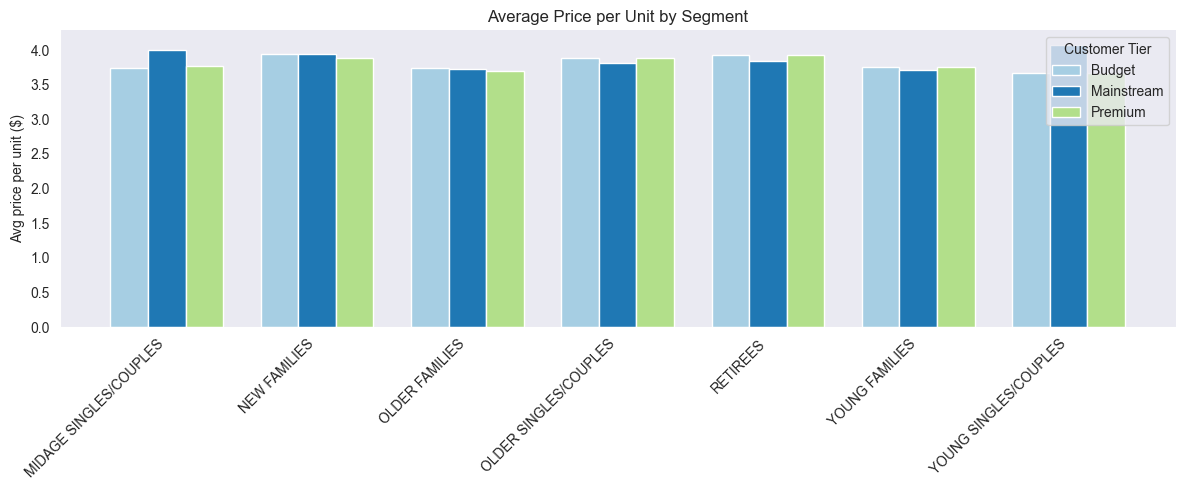

In [29]:
avg_price = (
    merged_data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .apply(lambda g: g["TOT_SALES"].sum() / g["PROD_QTY"].sum())
    .reset_index(name="AVG_PRICE_PER_UNIT")
)

fig, ax = plt.subplots(figsize=(12, 5))
tier_order = ["Budget", "Mainstream", "Premium"]
x = np.arange(len(avg_price["LIFESTAGE"].unique()))
lifestages = avg_price["LIFESTAGE"].unique()
width = 0.25

for i, tier in enumerate(tier_order):
    vals = [
        avg_price.loc[
            (avg_price["LIFESTAGE"] == ls) & (avg_price["PREMIUM_CUSTOMER"] == tier),
            "AVG_PRICE_PER_UNIT",
        ].values[0]
        for ls in lifestages
    ]
    ax.bar(x + i * width, vals, width, label=tier)

ax.set_xticks(x + width)
ax.set_xticklabels(lifestages, rotation=45, ha="right")
ax.set_ylabel("Avg price per unit ($)")
ax.set_title("Average Price per Unit by Segment")
ax.legend(title="Customer Tier")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


It seems that mid-age and young mainstream customers are paying the most per pack of chips, however paired with insights from the heatmap and total sales data reveal that purchase volume and life stage are the true drivers of overall revenue.

While the average price per unit is relatively stable across segments (hovering between $3.50 and $4.00), the heatmap highlights a clear behavioral split: Families (particularly Older Families) purchase the highest volume per transaction (up to 2.00 units), whereas Young Singles/Couples purchase the fewest (1.81 units) and also seem to pay more per unit. This volume difference explains the disparity in the Total Sales chart. Older Families are the dominant revenue source for the Budget tier (generating over $160k in sales), likely due to buying in bulk. Conversely, Young Singles/Couples and Retirees are the primary engines for the Mainstream tier.


<H3>T-test: price per unit, Mainstream vs Budget/Preium segments</H3>

In [31]:
merged_data["PRICE_PER_UNIT"] = merged_data["TOT_SALES"] / merged_data["PROD_QTY"]

target_lifestages = ["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"]

mainstream_prices = merged_data.loc[
    merged_data["LIFESTAGE"].isin(target_lifestages)
    & (merged_data["PREMIUM_CUSTOMER"] == "Mainstream"),
    "PRICE_PER_UNIT",
]
other_prices = merged_data.loc[
    merged_data["LIFESTAGE"].isin(target_lifestages)
    & (merged_data["PREMIUM_CUSTOMER"] != "Mainstream"),
    "PRICE_PER_UNIT",
]

t_stat, p_val = stats.ttest_ind(mainstream_prices, other_prices, alternative="greater")
print(f"Mainstream mean: ${mainstream_prices.mean():.3f}")
print(f"Budget/Premium mean: ${other_prices.mean():.3f}")
print(f"t-statistic: {t_stat:.2f}, p-value: {p_val:.2e}")

Mainstream mean: $4.046
Budget/Premium mean: $3.688
t-statistic: 40.83, p-value: 0.00e+00


The t-test confirms an earlier suspicion that mid-age and young mainstream customers are paying the most per pack of chips. This intuition is confirmed by a rigorous T-test, which reveals a statistically significant price gap (p-value ≈ 0): Mainstream customers in these segments pay an average of $4.05 per unit, compared to just $3.69 for their Budget and Premium counterparts.

However, the heatmap indicates a critical trade-off in behavior: while these customers pay a premium, they purchase the lowest volume per transaction (averaging ~1.8 units), whereas Families buy in bulk (up to 2.0 units). Consequently, the Total Sales chart shows that revenue for Singles/Couples is driven by the Mainstream tier's higher unit price, while revenue for Families is driven by the Budget tier's higher volume.

<H3>Affinity analysis: brand and pack size</H3>

Brand affinity (>1 = over-index vs rest of population):
BRAND
Tyrrells           1.236
Twisties           1.227
Kettle             1.204
Tostitos           1.204
Old El Paso        1.197
Pringles           1.195
Doritos            1.167
Cobs               1.151
Infuzions          1.141
Thins              1.066
Grain Waves        1.056
Cheezels           0.970
Smiths             0.768
French Fries       0.690
Cheetos            0.670
Red Rock Deli      0.663
Natural Chip Co    0.639
CCs                0.596
Sunbites           0.508
Woolworths         0.491
Burger Rings       0.447


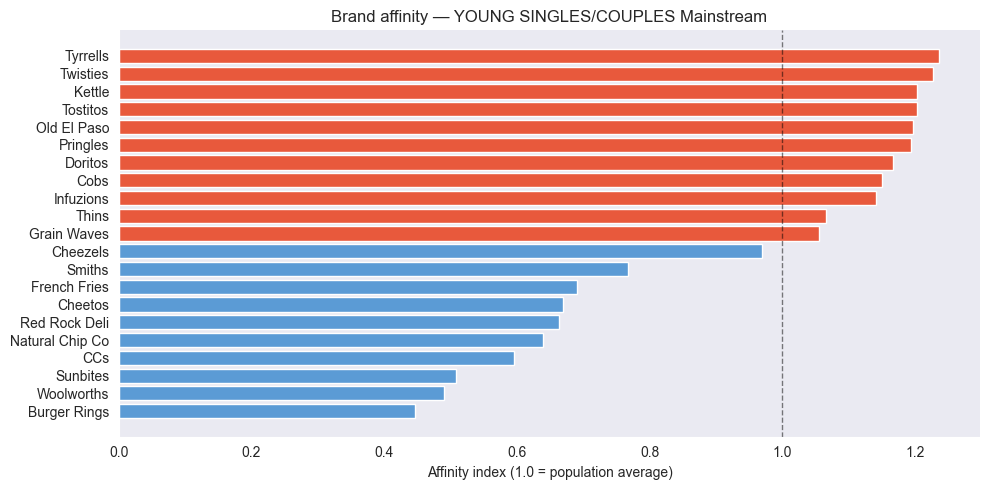


Pack size affinity:
WEIGHT
270.0    1.277
380.0    1.265
330.0    1.230
134.0    1.195
110.0    1.191
210.0    1.167
135.0    1.137
250.0    1.131
170.0    1.004
300.0    0.960
175.0    0.951
150.0    0.949
165.0    0.900
190.0    0.605
180.0    0.595
160.0    0.521
90.0     0.508
125.0    0.502
200.0    0.484
70.0     0.483
220.0    0.447


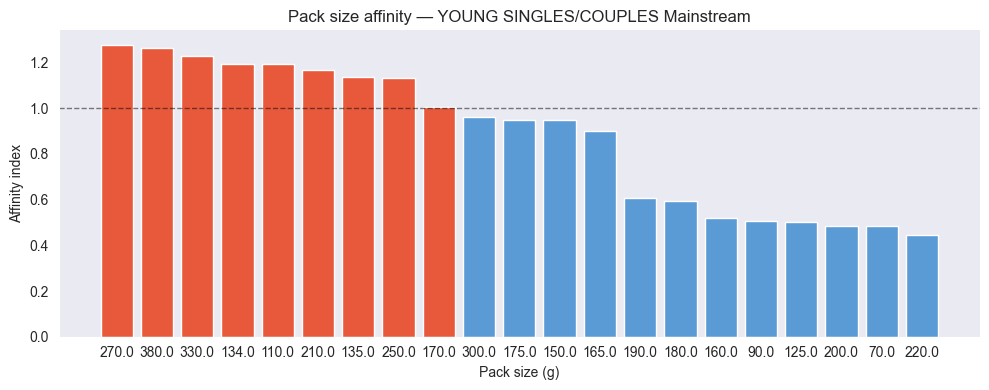

In [32]:
TARGET_LIFESTAGE = "YOUNG SINGLES/COUPLES"
TARGET_TIER = "Mainstream"

segment = merged_data[
    (merged_data["LIFESTAGE"] == TARGET_LIFESTAGE)
    & (merged_data["PREMIUM_CUSTOMER"] == TARGET_TIER)
]
other = merged_data[
    ~(
        (merged_data["LIFESTAGE"] == TARGET_LIFESTAGE)
        & (merged_data["PREMIUM_CUSTOMER"] == TARGET_TIER)
    )
]

qty_seg = segment["PROD_QTY"].sum()
qty_other = other["PROD_QTY"].sum()

#Brand affinity
brand_seg = segment.groupby("BRAND")["PROD_QTY"].sum() / qty_seg
brand_other = other.groupby("BRAND")["PROD_QTY"].sum() / qty_other
brand_affinity = (brand_seg / brand_other).dropna().sort_values(ascending=False)
brand_affinity.name = "affinity"

print("Brand affinity (>1 = over-index vs rest of population):")
print(brand_affinity.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#E8593C" if v >= 1 else "#5B9BD5" for v in brand_affinity.values]
ax.barh(brand_affinity.index[::-1], brand_affinity.values[::-1], color=colors[::-1])
ax.axvline(1, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Affinity index (1.0 = population average)")
ax.set_title(f"Brand affinity — {TARGET_LIFESTAGE} {TARGET_TIER}")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#Pack size (weight) affinity
weight_seg = segment.groupby("WEIGHT")["PROD_QTY"].sum() / qty_seg
weight_other = other.groupby("WEIGHT")["PROD_QTY"].sum() / qty_other
weight_affinity = (weight_seg / weight_other).dropna().sort_values(ascending=False)

print("\nPack size affinity:")
print(weight_affinity.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#E8593C" if v >= 1 else "#5B9BD5" for v in weight_affinity.values]
ax.bar(weight_affinity.index.astype(str), weight_affinity.values, color=colors)
ax.axhline(1, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Pack size (g)")
ax.set_ylabel("Affinity index")
ax.set_title(f"Pack size affinity — {TARGET_LIFESTAGE} {TARGET_TIER}")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The Brand Affinity chart reveals that this segment strongly favors brands like Tyrrells, Kettle, and Twisties (Affinity Index > 1.2), while actively avoiding store brands like Woolworths. This explains why their average unit price is higher, they are simply selecting premium SKUs. Furthermore, the Pack Size Affinity chart shows a polarized behavior: these customers prefer either large "sharing" bags (380g, 330g) or specific smaller snack sizes, largely ignoring the standard mid-range family packs (150g–200g). Finally, the Brand Share chart confirms that Kettle is the undisputed market leader across all demographics (consistently ~20-23% share), indicating that while niche brands drive preference for Young Singles, Kettle drives the actual volume.